# Hamiltonian Flow Matching — Hill Potential

Transports an 8-Gaussian mixture to a 2-moons distribution under the **Hill functional**
`V(x) = -α‖x‖²/2` using a fully analytical Gaussian path.

The closed-form σ(t) grows exponentially, reflecting the repulsive nature of the potential.

In [51]:
import sys, os
sys.path.insert(0, os.path.abspath('../../../'))

import torch
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions import MultivariateNormal
from torchdyn.core import NeuralODE

from torchcfm.hamiltonian import (
    CrowdNavObstaclePotential, ParticleBVPGaussianPath, ConfiguredPotential,
    MeanStdBVPGaussianPath,flow_matching_loss, 
    plot_trajectories_with_potential,
)
from torchcfm.optimal_transport import OTPlanSampler
from torchcfm.models.models_v2 import MLP
from torchcfm.utils import torch_wrapper

def to_numpy(x):
    return x.detach().cpu().numpy()

In [67]:

torch.manual_seed(42)

dim          = 2
batch_size   = 64
n_dataset    = 250   # number of pre-computed (x0, x1) pairs
n_iters      = 10_000
lr           = 1e-3
sigma_path   = 0.01
n_steps      = 150
tol          = 0.1

source_mean  = torch.tensor([-10.0, -0.0],device = device)
target_mean  = torch.tensor([10.0, 0.0],device = device)
gaussian_std = torch.tensor(1.0,device = device)
print(f'device: {device}')

device: cuda:2


## Potential, path and flow matcher

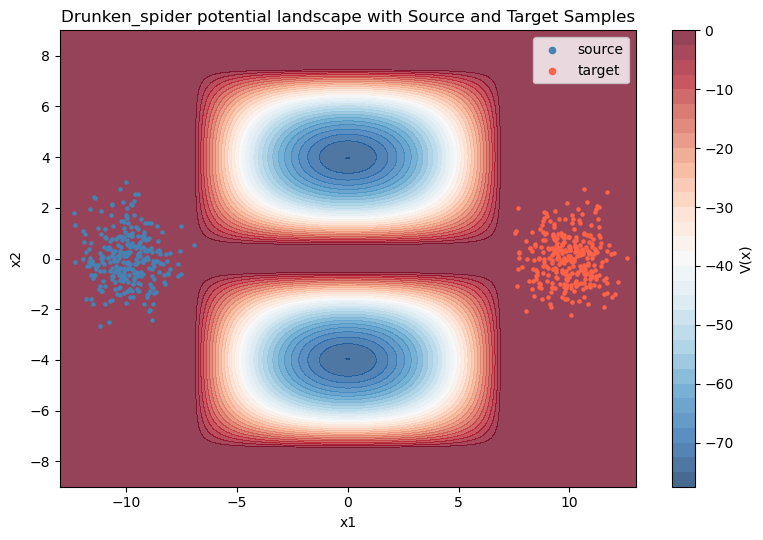

In [68]:
source_dist = MultivariateNormal(source_mean, gaussian_std**2 * torch.eye(dim, device=device))
target_dist = MultivariateNormal(target_mean, gaussian_std**2 * torch.eye(dim, device=device))


def sample_source(n):
    return source_dist.sample((n,)).to(device)


def sample_target(n):
    return target_dist.sample((n,)).to(device)


cfg_potential = {'linear': ('drunken_spider', -5e-3), 'interaction': None, 'internal': None} #
potential = ConfiguredPotential(cfg_potential)
stunnel_centers = torch.tensor([[5.0, 6.0], [-5.0, -6.0]], device=device)

# Visualize potential landscape with source and target samples.
x_grid = np.linspace(-13, 13, 180)
y_grid = np.linspace(-9, 9, 140)
X, Y = np.meshgrid(x_grid, y_grid)
xy = torch.tensor(np.stack([X.ravel(), Y.ravel()], axis=1), dtype=torch.float32, device=device)

with torch.no_grad():
    Z = to_numpy(potential.energy(xy)).reshape(Y.shape)

x0_vis = to_numpy(sample_source(300))
x1_vis = to_numpy(sample_target(300))


plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.75)
plt.colorbar(label='V(x)')
plt.scatter(x0_vis[:, 0], x0_vis[:, 1], s=5, c='steelblue', label='source')
plt.scatter(x1_vis[:, 0], x1_vis[:, 1], s=5, c='tomato', label='target')

plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title(f'{cfg_potential["linear"][0].capitalize()} potential landscape with Source and Target Samples')
plt.tight_layout()
plt.show()


## Visualise σ(t) schedule and potential

In [69]:
# path = ParticleBVPGaussianPath(potential, sigma=sigma_path, n_steps=n_steps, tol=tol)
path = MeanStdBVPGaussianPath(potential, sigma=sigma_path, n_steps=n_steps, tol=tol)
ot_sampler = OTPlanSampler(method='exact')

# Step 1: OT-couple the dataset.
x0_all = sample_source(n_dataset)
x1_all = sample_target(n_dataset)
x0_coupled, x1_coupled = ot_sampler.sample_plan(x0_all, x1_all)

print(f'Solving {n_dataset} mean/std BVPs (may take several minutes)...')

# Step 2: Pre-compute BVP for all pairs and drop non-converged solves.
states = path.batch_solve(x0_coupled, x1_coupled)
keep = path.success_mask
x0_coupled = x0_coupled[keep]
x1_coupled = x1_coupled[keep]
n_failed = int((~keep).sum().item())
n_dataset = x0_coupled.shape[0]
print(
    f'Done. kept {n_dataset} / {keep.numel()} BVPs; failed {n_failed}. '
    f'states: {states.shape}  (pairs, time-steps, state-dim [mu, mu_dot, sigma, sigma_dot])'
)
if n_failed:
    preview = list(path.failure_messages.items())[:5]
    print(f'First failures: {preview}')


Solving 250 mean/std BVPs (may take several minutes)...


KeyboardInterrupt: 

IndexError: index 12 is out of bounds for axis 0 with size 12

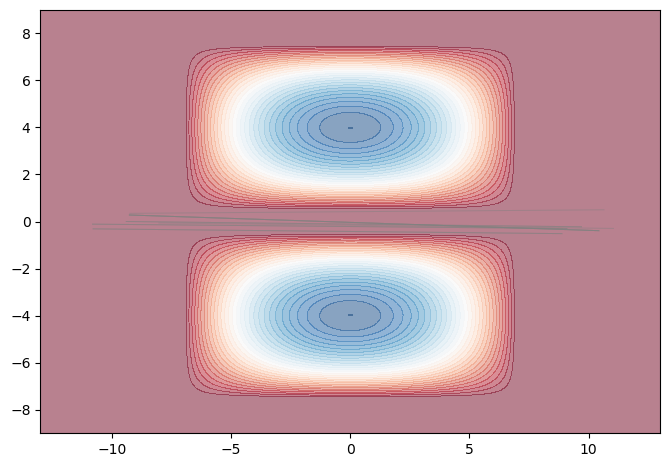

In [70]:
# Visualize a few BVP-solved trajectories.
n_show = min(n_dataset, n_dataset)
traj_bvp = to_numpy(states[:n_show, :, :dim])  # (pairs, time, x-position)
x0_coupled_plot = to_numpy(x0_coupled[:n_show])
x1_coupled_plot = to_numpy(x1_coupled[:n_show])
stunnel_centers_plot = to_numpy(stunnel_centers)

plt.figure(figsize=(8, 5.5))
plt.contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.5)
for i in range(n_show):
    plt.plot(traj_bvp[i, :, 0], traj_bvp[i, :, 1], 'gray', alpha=0.45, linewidth=0.7)
plt.scatter(x0_coupled_plot[:, 0], x0_coupled_plot[:, 1], s=8, c='steelblue', label='x0')
plt.scatter(x1_coupled_plot[:, 0], x1_coupled_plot[:, 1], s=8, c='tomato', label='x1')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(markerscale=2)
plt.title('BVP reference trajectories')
plt.tight_layout()
plt.show()

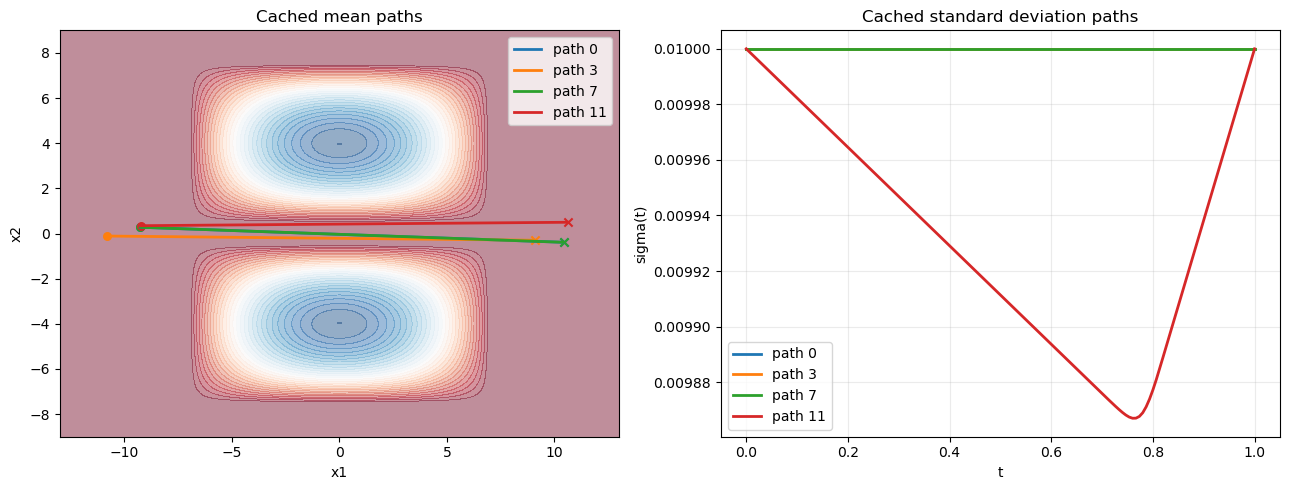

In [ ]:
# Plot four cached mean paths and their standard deviation schedules.
n_mean_std_show = min(4, states.shape[0])
plot_idx = torch.linspace(0, states.shape[0] - 1, n_mean_std_show).long()
t_state = to_numpy(path.t_grid[:states.shape[1]])
mean_paths = to_numpy(states[plot_idx, :, :dim])
sigma_paths = to_numpy(states[plot_idx, :, 2 * dim])
colors = plt.cm.tab10(np.arange(n_mean_std_show))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].contourf(X, Y, Z, levels=35, cmap='RdBu_r', alpha=0.45)
for j, idx in enumerate(plot_idx.tolist()):
    axes[0].plot(mean_paths[j, :, 0], mean_paths[j, :, 1], color=colors[j], linewidth=2.0, label=f'path {idx}')
    axes[0].scatter(mean_paths[j, 0, 0], mean_paths[j, 0, 1], s=30, color=colors[j], marker='o')
    axes[0].scatter(mean_paths[j, -1, 0], mean_paths[j, -1, 1], s=35, color=colors[j], marker='x')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].set_title('Cached mean paths')
axes[0].legend()

for j, idx in enumerate(plot_idx.tolist()):
    axes[1].plot(t_state, sigma_paths[j], color=colors[j], linewidth=2.0, label=f'path {idx}')
axes[1].set_xlabel('t')
axes[1].set_ylabel('sigma(t)')
axes[1].set_title('Cached standard deviation paths')
axes[1].grid(alpha=0.25)
axes[1].legend()

plt.tight_layout()
plt.show()


## Model

In [ ]:
model     = MLP(dim, out_dim=dim, w=64,time_varying=True).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 8,706


## Training

In [ ]:
model.train()
losses = []

for k in range(n_iters):
    optimizer.zero_grad()
    x0 = sample_8gaussians(batch_size).to(device)
    x1 = sample_moons(batch_size).to(device)

    t, xt, ut = fm.sample_location_and_conditional_flow(x0, x1)
    vt   = model(torch.cat([xt, t], dim=-1))
    loss = flow_matching_loss(vt, ut)

    loss.backward()
    optimizer.step()
    losses.append(loss.item())

    if k % 5000 == 0 or k == n_iters - 1:
        print(f'step {k:5d}: loss = {loss.item():.5f}')

step     0: loss = 7.46178
step  5000: loss = 0.15022
step 10000: loss = 0.12855
step 15000: loss = 0.08707
step 20000: loss = 0.09571
step 25000: loss = 0.06569
step 30000: loss = 0.18116
step 35000: loss = 0.13632
step 40000: loss = 0.05627
step 45000: loss = 0.05916
step 49999: loss = 0.08012


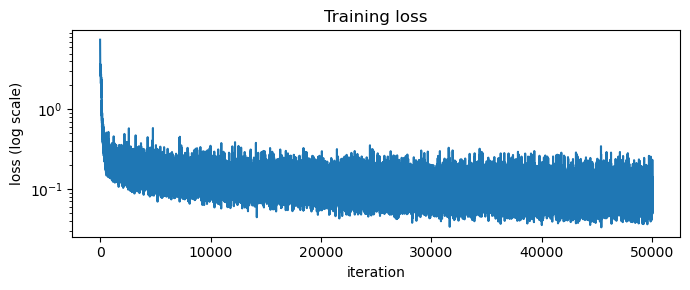

In [ ]:
plt.figure(figsize=(7, 3))
plt.semilogy(losses)
plt.xlabel('iteration'); plt.ylabel('loss (log scale)')
plt.title('Training loss'); plt.tight_layout(); plt.show()

## Evaluation

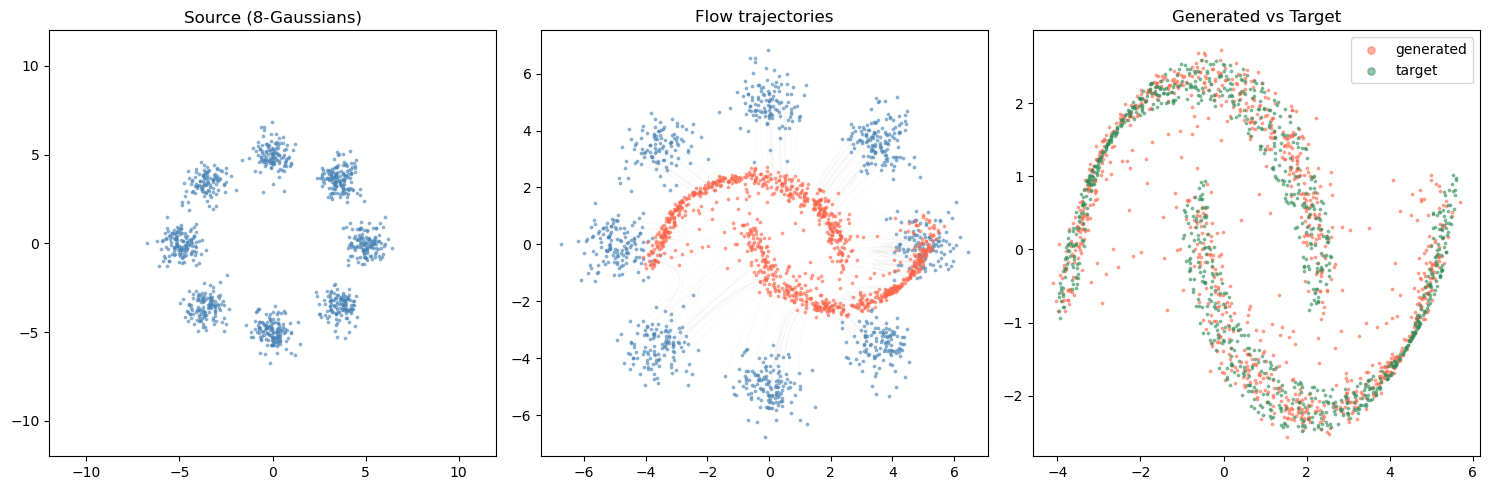

In [ ]:
model.eval()
node = NeuralODE(torch_wrapper(model), sensitivity='adjoint', solver='dopri5')

with torch.no_grad():
    traj = node.trajectory(
        sample_8gaussians(1000).to(device),
        t_span=torch.linspace(0, 1, 100, device=device),
    )

traj = traj.cpu()
x1_ref = sample_moons(1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(traj[0, :, 0], traj[0, :, 1], s=3, alpha=0.5, c='steelblue')
axes[0].set_title('Source (8-Gaussians)'); axes[0].set_xlim(-12, 12); axes[0].set_ylim(-12, 12)

for i in range(0, 1000, 5):
    axes[1].plot(traj[:, i, 0], traj[:, i, 1], alpha=0.05, c='gray', linewidth=0.5)
axes[1].scatter(traj[0, :, 0], traj[0, :, 1], s=3, alpha=0.5, c='steelblue')
axes[1].scatter(traj[-1, :, 0], traj[-1, :, 1], s=3, alpha=0.5, c='tomato')
axes[1].set_title('Flow trajectories')

axes[2].scatter(traj[-1, :, 0], traj[-1, :, 1], s=3, alpha=0.5, c='tomato', label='generated')
axes[2].scatter(x1_ref[:, 0], x1_ref[:, 1], s=3, alpha=0.5, c='seagreen', label='target')
axes[2].legend(markerscale=3); axes[2].set_title('Generated vs Target')

plt.tight_layout(); plt.show()

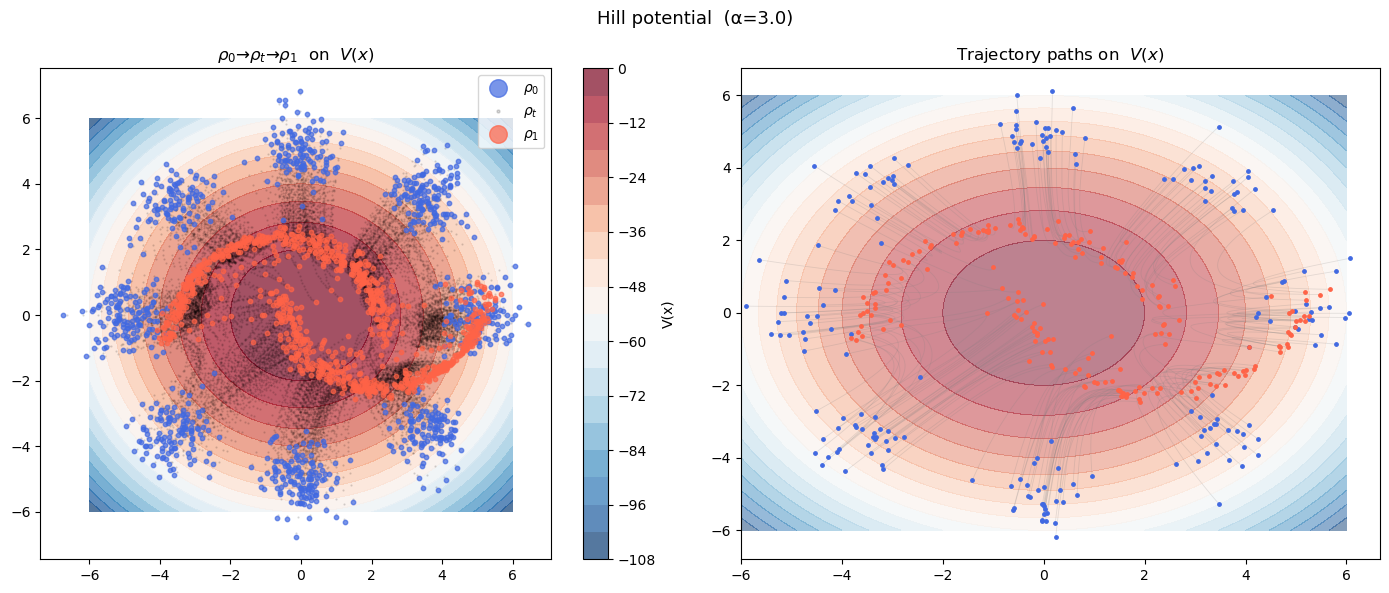

In [ ]:
# Trajectories overlaid on potential energy landscape
# ρ₀ (source) → ρ_t (all intermediate positions) → ρ₁ (target)
n_show = 1000
n_lines = 200

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cf = axes[0].contourf(X, Y, Z, levels=20, cmap='RdBu_r', alpha=0.7)
plt.colorbar(cf, ax=axes[0], label='V(x)')
axes[0].scatter(traj[0, :n_show, 0], traj[0, :n_show, 1],
                s=10, alpha=0.7, c='royalblue', label=r'$\rho_0$', zorder=3)
axes[0].scatter(traj[1:-1:5, :n_show, 0].reshape(-1), traj[1:-1:5, :n_show, 1].reshape(-1),
                s=0.3, alpha=0.15, c='black', label=r'$\rho_t$')
axes[0].scatter(traj[-1, :n_show, 0], traj[-1, :n_show, 1],
                s=10, alpha=0.7, c='tomato', label=r'$\rho_1$', zorder=3)
axes[0].legend(markerscale=4)
axes[0].set_title(r'$\rho_0 \to \rho_t \to \rho_1$  on  $V(x)$')

axes[1].contourf(X, Y, Z, levels=20, cmap='RdBu_r', alpha=0.5)
for i in range(n_lines):
    axes[1].plot(traj[:, i, 0], traj[:, i, 1], 'gray', alpha=0.2, linewidth=0.6)
axes[1].scatter(traj[0, :n_lines, 0], traj[0, :n_lines, 1], s=6, c='royalblue', zorder=3)
axes[1].scatter(traj[-1, :n_lines, 0], traj[-1, :n_lines, 1], s=6, c='tomato', zorder=3)
axes[1].set_title(r'Trajectory paths on  $V(x)$')

plt.suptitle(f'Hill potential  (α={alpha})', fontsize=13)
plt.tight_layout(); plt.show()